In [1]:
# illustrative example of use GEMS 

## Injection procedure example 

> Version: 1.0
> 
> Container Size: Large
>
> Description: In this notebook, we present an illustrative example of the use of the GEMS package, where we make a coadd from a local butler, in particular using visit_images with an injected stamp.

In [2]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

!python --version

Release r29.2.0 (RSP Build 2648)
lsst_distrib          gc675d380bf+f75de59d28 	current v29_2_0 v29_2_0_rc1 setup
Python 3.12.11


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Loading modules
import numpy as np
import gems
import pandas as pd
import matplotlib.pyplot as plt

#from astropy.io import fits
from lsst.daf.butler import Butler

In [158]:
LOCAL_REPO = "./local_butler" 

In [6]:
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  direct_injected_run                                       RUN    
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250

In [7]:
!butler query-datasets $LOCAL_REPO visit_image \
  --collections local_with_injection \
  --limit 15


    type            run                          id                  instrument detector     visit     band day_obs  physical_filter
----------- ------------------- ------------------------------------ ---------- -------- ------------- ---- -------- ---------------
visit_image direct_injected_run 108c0198-b654-4696-963b-cc8c07373089 LSSTComCam        2 2024110900195    u 20241109            u_02
visit_image direct_injected_run 35036dea-1c1d-4b64-a8fb-fb94bd16c7a1 LSSTComCam        5 2024110900198    u 20241109            u_02
visit_image direct_injected_run b4dce04c-c76a-4e5d-bfe8-c00865555bbf LSSTComCam        8 2024110900199    u 20241109            u_02
visit_image direct_injected_run f818c712-fb03-4939-b67a-9902e846bcf8 LSSTComCam        5 2024110900200    u 20241109            u_02
visit_image direct_injected_run 2f7b7e0f-9b16-41ca-9b87-0952b88ae7ad LSSTComCam        8 2024110900202    u 20241109            u_02
visit_image direct_injected_run 7068a080-4714-4845-964e-6e945727f70d

In [43]:
# Making a DataFrame with the visit, and its respective band
lbutler = Butler(LOCAL_REPO, collections='local_with_injection')

refs = lbutler.query_datasets("visit_image")
visits_selected = {'visit_id': [], 'band': []}
for ref in refs:
    visits_selected['visit_id'].append(ref.dataId.get('visit'))
    visits_selected['band'].append(ref.dataId.get('band'))

pd_visits_selected = pd.DataFrame(visits_selected)
pd_visits_selected

,visit_id,band
0,2024110900195,u
1,2024110900203,u
2,2024120100187,u
3,2024120100188,u
4,2024110900198,u
5,2024110900200,u
6,2024110900199,u
7,2024110900202,u


### Making a deep coadd

In [88]:
# Identify visit images around location
ra_deg, dec_deg = (53.2, -27.8)
loc_data = ra_deg, dec_deg


In [46]:
gems.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection="local_with_injection",
                          my_collection_name='custom_coadd',
                          sky_coordinates=True,
                          SAVE_FITS=False,
                          out=False)

[INFO] Metadata saved: ./local_butler/custom_coadd_info.txt


#### The information of the custom coadd is in the file "custom_coadd_info.txt" inside of the repo


In [48]:
local_repo_path = LOCAL_REPO #os.path.join(os.getenv("HOME"), LOCAL_REPO) 
info_txt_path = os.path.join(local_repo_path, "custom_coadd_info.txt")

with open(info_txt_path, "r") as f:
        info = json.load(f)

info

{'repo_path': './local_butler',
 'collection': 'custom_coadd/20260303T072414Z',
 'coadd_type': 'deep_coadd_predetection',
 'tract': 5063,
 'patch': '34',
 'bands': ['u'],
 'instrument': 'LSSTComCam',
 'skymap': 'lsst_cells_v1'}

In [53]:
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd                                                CHAINED
  custom_coadd/20260303T072414Z                             RUN    
  custom_coadd/inputs                                       TAGGED 
custom_coadd/20260303T072414Z                               RUN    
custom_coadd/inputs                                         TAGGED 
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601              

#### Add the coadd to the local_with_injection chain

In [55]:
regist_lbutler = Butler(LOCAL_REPO, writeable=True).registry

chain_name = "local_with_injection"
chain_local_with_injection = list(registry.getCollectionChain(chain_name))
chain_custom_coadd = list(registry.getCollectionChain("custom_coadd"))

# check and add
for el in chain_custom_coadd:
    if el not in chain_local_with_injection:
        chain_local_with_injection.append(el)

# Apply chain
regist_lbutler.setCollectionChain(chain_name, chain_local_with_injection)

In [60]:
# removing the custom_coadd chain
regist_lbutler.removeCollection("custom_coadd")
#regist_lbutler.removeCollection("custom_coadd/inputs")

In [61]:
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd/20260303T072414Z                               RUN    
custom_coadd/inputs                                         TAGGED 
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  direct_injected_run                           

In [67]:
lbutler = Butler(LOCAL_REPO, collections='local_with_injection')

coadd_results_butler = {}
for band in info['bands']:
    coadd = lbutler.get(info['coadd_type'], tract=info['tract'], patch=int(info['patch']),
                band=band, instrument=info['instrument'], skymap=info['skymap'],)
    coadd_results_butler[band] = coadd

In [68]:
coadd_results_butler

{'u': <lsst.afw.image._exposure.ExposureF at 0x78e2a09329f0>}

### Comparing with the full deep_coadd

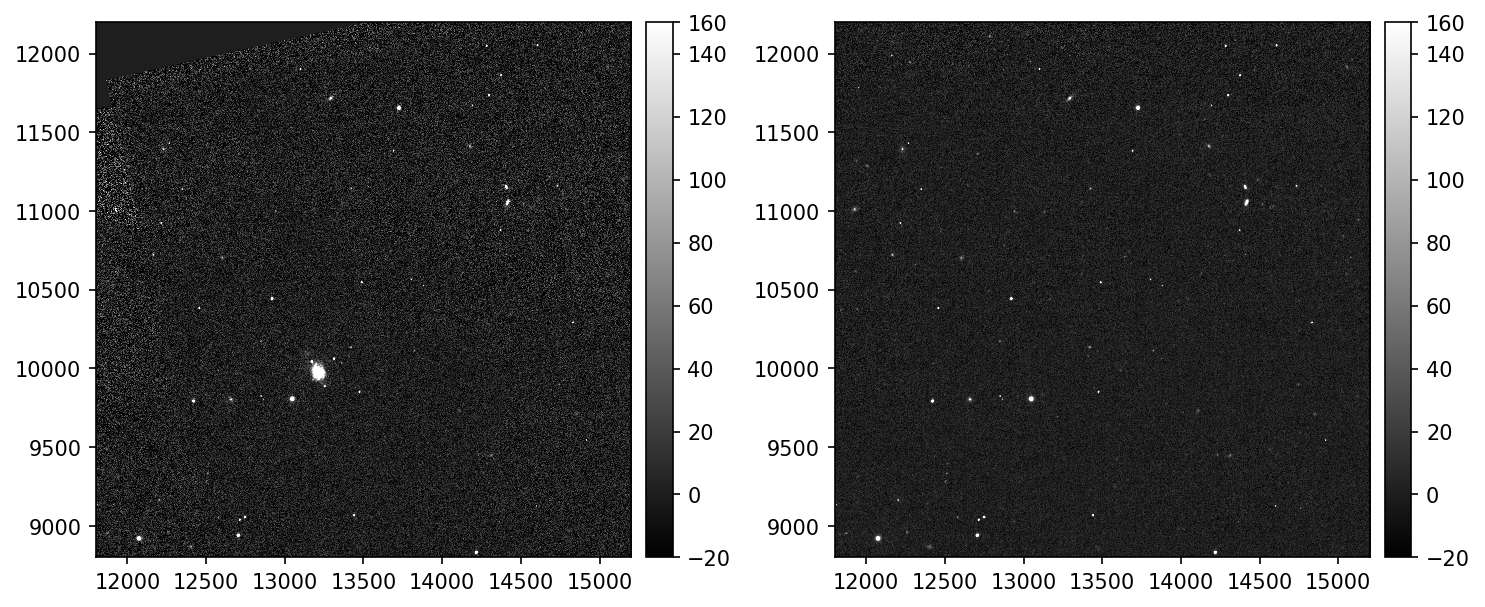

In [70]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")

lbutler = Butler(LOCAL_REPO, collections="local_main_chain")
coadd = lbutler.get('deep_coadd', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34})

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd_results_butler['u'].image)


plt.sca(ax[1])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd.image)

plt.tight_layout()

## Comparing with a coadd with the same visit number, but without the injected stamp

In [71]:
gems.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection="local_main_chain",  # important change the collection
                          my_collection_name='custom_coadd_without_stamp',
                          sky_coordinates=True,
                          SAVE_FITS=False,
                          out=False,
                          meta_data_name ="custom_coadd_info_without_stamp")

[INFO] Metadata saved: ./local_butler/custom_coadd_info_without_stamp.txt


In [72]:
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd/20260303T072414Z                               RUN    
custom_coadd/inputs                                         TAGGED 
custom_coadd_without_stamp                                  CHAINED
  custom_coadd_without_stamp/20260303T080727Z               RUN    
  custom_coadd_without_stamp/inputs                         TAGGED 
custom_coadd_without_stamp/20260303T080727Z                 RUN    
custom_coadd_without_stamp/inputs                           TAGGED 
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                       

In [73]:
# loading 

local_repo_path = LOCAL_REPO #os.path.join(os.getenv("HOME"), LOCAL_REPO) 
info_txt_path_2 = os.path.join(local_repo_path, "custom_coadd_info_without_stamp.txt")

coadd_results_without_stamp = gems.load_custom_coadd_from_file(info_txt_path_2)

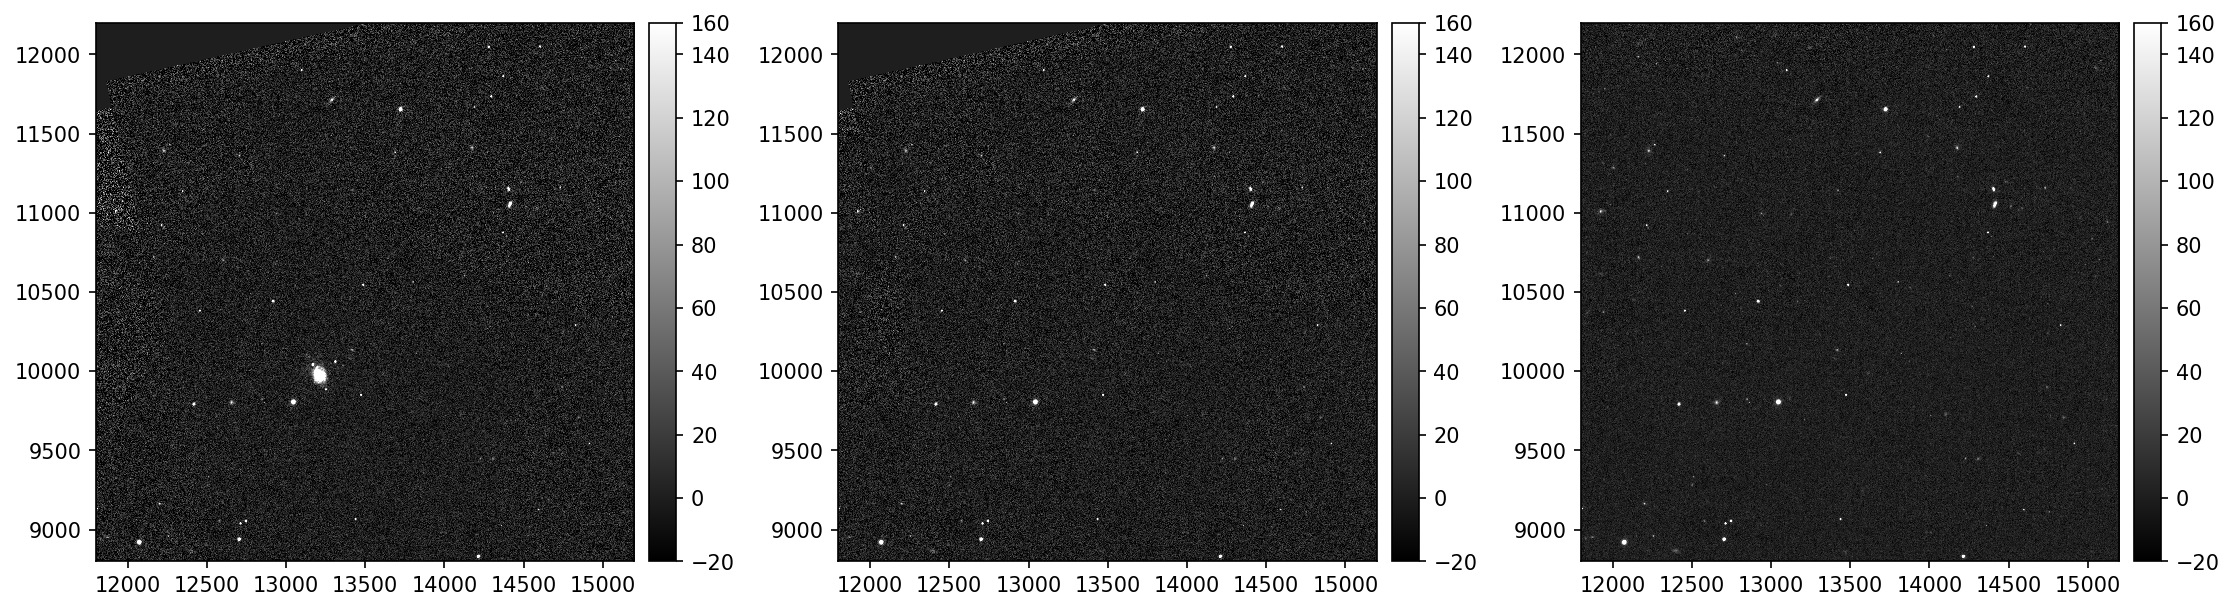

In [75]:
lbutler = Butler(LOCAL_REPO, collections="local_main_chain")
coadd = lbutler.get('deep_coadd', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34})

fig, ax = plt.subplots(1, 3, figsize=(15, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd_results_butler['u'].image)

plt.sca(ax[1])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd_results_without_stamp['u'].image)

plt.sca(ax[2])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd.image)

plt.tight_layout()

## Comparison of both coadds

[INFO] Converted LSST SkyWcs -> Astropy WCS


<string>:75: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


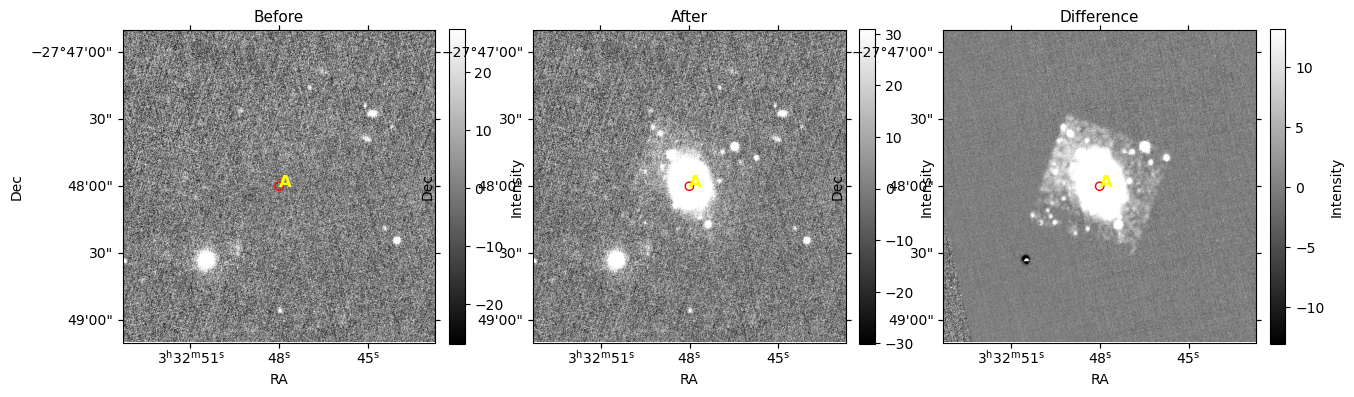

In [172]:
# Simple comparison (subtraction of both)
points = [loc_data]
before = coadd_results_without_stamp['u']
after = coadd_results_butler['u']

# necessary because the corner no is (0, 0)
bbox = after.getBBox()
xmin = bbox.getMinX()
xmax = bbox.getMaxX()
ymin = bbox.getMinY()
ymax = bbox.getMaxY()

gems.injection_steps(before,
                   after,
                   points,
                   diference=True,
                   cutout_radius_arcsec=70,  # arcsec  10
                   grid=False, percentiles=[5, 95],
                   extent=[xmin, xmax, ymin, ymax]
                  )

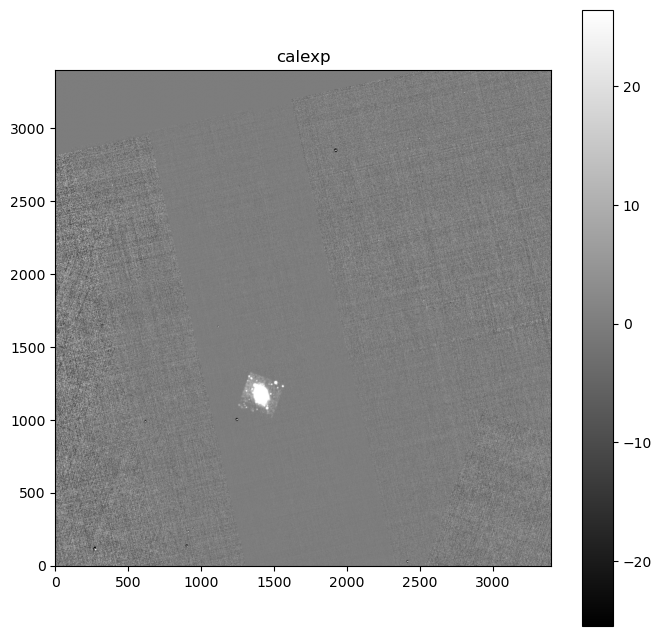

In [82]:
diff = coadd_results_butler['u'].clone()
diff.image.array[:] = coadd_results_butler['u'].image.array - coadd_results_without_stamp['u'].image.array

plt.figure(figsize=(8,8))
plt.imshow(diff.image.array, origin="lower", cmap="gray",
           vmin=np.percentile(diff.image.array, 1),
           vmax=np.percentile(diff.image.array, 99))
plt.colorbar()
plt.title("calexp")
plt.show()